In [ ]:
!git clone "https://github.com/thaortrinh/pm25-hcmc.git"

fatal: destination path 'pm25-hcmc' already exists and is not an empty directory.


In [ ]:
!pip install lazypredict

In [ ]:
!pip install catboost

In [ ]:
!pip install optuna

In [ ]:
!pip install optuna-integration

##🌟 PM2.5 Forecasting Pipeline: Từ Feature Engineering đến Chọn Mô Hình

Trong dự án này, mục tiêu là dự báo PM2.5 ở giờ kế tiếp bằng cách kết hợp ba lớp thông tin chính:

lịch sử PM2.5 để học quán tính và xu hướng,
khí tượng và chu kỳ thời gian để mô tả điều kiện môi trường,
bối cảnh con người và động lực học vật lý để giải thích cơ chế tăng giảm ô nhiễm.

Điểm quan trọng là mô hình không chỉ “nhìn số”, mà phải hiểu được vì sao PM2.5 thay đổi.

###🌀 1. Nhóm Trí Nhớ PM2.5 (Autoregressive Features)

Nhóm này là nền móng của bài toán dự báo.

pm25_lag_nh

Ví dụ:

pm25_lag_1h
pm25_lag_6h
pm25_lag_24h
Ý nghĩa

PM2.5 có quán tính theo thời gian. Nếu hiện tại bụi đang cao, thì giờ kế tiếp thường vẫn còn chịu ảnh hưởng từ vài giờ trước đó.

Lag ngắn hạn giúp mô hình học tác động gần nhất
Lag dài hơn giúp mô hình học chu kỳ theo ngày hoặc theo tuần
Vì sao phải có

Nếu bỏ nhóm này, mô hình gần như bị mù với “trí nhớ” của chính PM2.5.

###📈 2. Nhóm Thống Kê Trượt & Xu Hướng
pm25_roll_mean / pm25_roll_std

Ví dụ:

trung bình trượt 6h, 12h, 24h
độ lệch chuẩn trượt
pm25_ewm

Trung bình lũy thừa, ưu tiên dữ liệu gần hiện tại hơn.

Ý nghĩa

Các biến này giúp mô hình:

làm mịn chuỗi dữ liệu,
giảm tác động của nhiễu ngắn hạn,
nhận biết giai đoạn PM2.5 đang ổn định hay dao động mạnh.
Cách hiểu đơn giản

Lag cho biết “đã xảy ra gì”, còn rolling statistics cho biết “xu hướng gần đây đang ra sao”.

###🌡️ 3. Nhóm Lịch Sử Khí Tượng (Meteorological History)
Weather lags

Các biến như:

nhiệt độ,
độ ẩm,
mưa,
gió,
lớp biên khí quyển

được tạo trễ theo nhiều mốc thời gian.

Ý nghĩa

Khí tượng không phải lúc nào cũng tác động ngay lập tức.

Ví dụ:

mưa vài giờ trước có thể làm bụi giảm dần,
gió yếu kéo dài làm bụi tích tụ,
lớp biên thấp làm không khí khó khuếch tán.
Vì sao cần

Nếu chỉ nhìn khí tượng ở đúng thời điểm hiện tại, mô hình có thể bỏ lỡ các tác động có độ trễ vật lý.

###📅 4. Nhóm Chu Kỳ Thời Gian & Hướng Gió (Cyclical Patterns)
hour_sin / hour_cos

Dùng để mã hóa giờ trong ngày.

wind_sin / wind_cos

Dùng để mã hóa hướng gió theo dạng vòng tròn.

Ý nghĩa

Các biến như giờ trong ngày hay hướng gió có tính chu kỳ, không phải tuyến tính.

Ví dụ:

23h và 0h thực ra rất gần nhau,
359° và 1° gần như cùng một hướng.
Vì sao phải dùng sin/cos

Nếu dùng số thô, mô hình sẽ hiểu sai khoảng cách giữa các giá trị chuyển tiếp.

###🏢 5. Nhóm Bối Cảnh & Hoạt Động Con Người
Các biến điển hình
day_of_week
is_weekend
season
rush_hour_weekday
is_night
Ý nghĩa

PM2.5 không chỉ do thời tiết mà còn do hành vi phát thải của con người:

giao thông giờ cao điểm,
khác biệt giữa ngày thường và cuối tuần,
đặc trưng theo mùa,
hoạt động đô thị ban đêm.
Vì sao cần

Nhóm này giúp mô hình hiểu được “nhịp sống” của thành phố, chứ không chỉ nhìn khí tượng.

###⚡ 6. Nhóm Động Lực Học Vật Lý (Physical Dynamics)
ventilation_coeff

Đại diện cho khả năng khuếch tán bụi trong khí quyển.

wind_magnitude / wind_stagnation_index

Mô tả cường độ gió và mức độ gió lặng.

is_stagnant_humid

Đánh dấu trạng thái ẩm cao + gió yếu, là điều kiện dễ giữ bụi.

dew_point

Bổ sung thông tin về trạng thái ẩm của khí quyển.

pm25_delta / pm25_acceleration

Đo tốc độ thay đổi và “gia tốc” thay đổi của PM2.5.

Ý nghĩa chung

Nhóm này giúp mô hình học các cơ chế như:

bụi bị giữ lại khi không khí tù,
bụi tăng nhanh khi xu hướng ngắn hạn đổi chiều,
điều kiện khí quyển nào khiến ô nhiễm khó thoát ra ngoài.
Nói ngắn gọn

Đây là phần biến “dữ liệu môi trường” thành “câu chuyện vật lý”.

###🎯 7. Target và Kiểm Tra Dữ Liệu
target

Biến mục tiêu là:

PM2.5 của giờ kế tiếp
Cách tạo

Thường dùng:

target = pm25_avg.shift(-1)
Ý nghĩa

Ta dùng toàn bộ thông tin hiện tại để dự báo tương lai rất gần.

Kiểm tra dữ liệu

Những dòng bị thiếu ở các cột lag hoặc target phải được loại bỏ trước khi train.

Nếu không, mô hình sẽ học từ dữ liệu bẩn, mà cái này thì giống pha phân bón sai công thức: nhìn ngoài đẹp nhưng phun xuống là biết mặt nhau ngay.

###🧪 8. Vì sao dùng Time-Series Split thay vì train_test_split thông thường
Lý do chính

Đây là bài toán dự báo theo thời gian, nên dữ liệu phải được chia theo thứ tự thời gian.

Không dùng random split vì:
mô hình có thể học từ dữ liệu “tương lai”
rồi được test trên dữ liệu “quá khứ”
dẫn đến đánh giá ảo, đẹp giả trân
Dùng time-series split vì:
đúng với bối cảnh thực tế
train bằng dữ liệu quá khứ
kiểm tra trên dữ liệu xảy ra sau đó
Ý nghĩa

Cách chia dữ liệu phải mô phỏng đúng cách mô hình sẽ được dùng ngoài đời.

###📚 9. Vì sao chia thành Train / Validation / Test
Train

Dùng để học mô hình.

Validation

Dùng để:

chọn tham số,
theo dõi overfitting,
dùng early stopping,
so sánh mô hình.
Test

Dùng để đánh giá cuối cùng.

Vì sao không chỉ train/test

Nếu vừa tuning vừa nhìn test liên tục, thì test không còn là test nữa.

Ý nghĩa

Ba tập dữ liệu giúp việc đánh giá công bằng hơn và tránh tự lừa mình.

###🤖 10. Vì sao CatBoost Regressor là mô hình tốt nhất

Trong dự án này, CatBoost là mô hình cho kết quả tốt nhất vì nó phù hợp rất mạnh với dạng dữ liệu hiện có.

Lý do 1: phù hợp với dữ liệu bảng hỗn hợp

Dữ liệu có:

biến số,
biến lag,
biến khí tượng,
biến danh mục như mùa và thời điểm trong ngày.

CatBoost xử lý kiểu dữ liệu này rất tốt.

Lý do 2: xử lý categorical features tốt

Các biến như Season, time_of_the_day được CatBoost xử lý tự nhiên hơn nhiều mô hình khác.

Lý do 3: bắt được tương tác phi tuyến

PM2.5 không tăng giảm theo kiểu tuyến tính đơn giản. Nó là kết quả của:

PM quá khứ,
thời tiết,
độ ẩm,
gió,
hoạt động con người.

CatBoost học tốt các tương tác kiểu này.

Lý do 4: tổng quát hóa tốt hơn

So với LightGBM và stacking, CatBoost có thể đã đạt được điểm cân bằng tốt hơn giữa:

độ mạnh mô hình,
khả năng tổng quát hóa,
và độ ổn định.
###🧠 11. Vì sao CatBoost tốt hơn LightGBM và Stacking
So với LightGBM

LightGBM cũng mạnh, nhưng trong bài toán này có thể:

nhạy hơn với cách xử lý categorical,
hoặc chưa tận dụng tốt bằng CatBoost trên tập đặc trưng hiện tại.
So với Stacking

Stacking không phải lúc nào cũng tốt hơn.

Nó chỉ mạnh khi các base models:

học ra các góc nhìn khác nhau,
và mắc lỗi khác nhau một cách hữu ích.

Nếu CatBoost và LightGBM đã dự đoán khá giống nhau, stacking chỉ giống như “họp thêm một cuộc họp nữa”, chưa chắc ra quyết định khôn hơn.

Ý nghĩa

Mô hình phức tạp hơn không đồng nghĩa với mô hình tốt hơn.

###⚙️ 12. Vì sao dùng các tham số đó cho CatBoost
iterations

Số lượng cây tối đa. Đặt cao để mô hình có đủ sức học, nhưng sẽ dừng sớm nếu không còn cải thiện.

learning_rate

Điều chỉnh tốc độ học.

nhỏ hơn → học chậm hơn nhưng ổn định hơn
lớn quá → dễ học quá đà
depth

Độ sâu cây quyết định mức độ phức tạp của quan hệ mà mô hình có thể học.

l2_leaf_reg

Regularization để giảm overfitting.

subsample / bootstrap_type

Giúp mô hình không học quá cứng trên toàn bộ dữ liệu, tăng khả năng tổng quát hóa.

od_type / od_wait

Cơ chế early stopping để ngăn mô hình tiếp tục học khi validation không còn cải thiện.

Ý chính

Các tham số này không phải chọn ngẫu nhiên. Chúng được dùng để cân bằng giữa:

học đủ mạnh,
nhưng không học quá mức.

###📏 13. Các chỉ số đánh giá mô hình
RMSE

Phạt nặng hơn với các lỗi lớn. Phù hợp khi ta quan tâm các dự báo sai nhiều.

MAE

Dễ hiểu hơn vì là sai số tuyệt đối trung bình.

R²

Cho biết mô hình giải thích được bao nhiêu biến thiên của PM2.5.

MSE

Là dạng bình phương của sai số, hữu ích khi so sánh tối ưu hóa.

Ý nghĩa chung

Không nên chỉ nhìn một chỉ số. Cần xem nhiều thước đo để hiểu mô hình tốt theo cách nào.

###🚀 14. Quy trình tổng thể để người ngoài dự án có thể hiểu
Thu thập dữ liệu PM2.5, khí tượng và lịch thời gian theo từng giờ
Tạo feature engineering để mô tả:
trí nhớ PM2.5,
chu kỳ thời gian,
bối cảnh con người,
động lực học vật lý
Tạo target là PM2.5 ở giờ kế tiếp
Chia dữ liệu theo thời gian thành:
train,
validation,
test
Train nhiều mô hình khác nhau
Dùng validation để chọn mô hình và tham số
Đánh giá cuối cùng trên test
Chọn mô hình thắng cuộc: CatBoost Regressor

##🎯 Tổng Kết

Dự án này thành công vì không chỉ “ném dữ liệu vào mô hình”, mà thiết kế pipeline theo đúng bản chất của bài toán dự báo PM2.5:

dùng feature engineering để mô tả quán tính, khí tượng, chu kỳ và cơ chế vật lý,
dùng time-series split để tránh leakage,
dùng train/validation/test để đánh giá công bằng,
và chọn CatBoost vì nó phù hợp nhất với cấu trúc dữ liệu và cho hiệu năng tốt nhất.

Nói gọn một câu:

Mô hình thắng không phải vì nó nghe sang, mà vì nó hiểu dữ liệu đúng cách.

### 1. Feature Engineering

This section consolidates all the steps involved in creating new, informative features from the raw data. This includes time-based features, lag and rolling statistics, cyclical features, and interaction terms.

In [ ]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
from datetime import date

# Load the dataset
pm25_df = pd.read_csv("./pm25-hcmc/data/processed/pm25_weather_merged.csv")

# Ensure datetime is in datetime format and set as index for time-series operations
pm25_df['datetime'] = pd.to_datetime(pm25_df['datetime'])
pm25_df = pm25_df.set_index('datetime').sort_index()

# Drop 'is_pm25_missing' as decided
pm25_df.drop(columns=['is_pm25_missing'], inplace=True)

# Add 'Season' column
def get_season(month):
    if 3 <= month <= 5: return 'Spring'
    elif 6 <= month <= 8: return 'Summer'
    elif 9 <= month <= 11: return 'Autumn'
    else: return 'Winter'
pm25_df['Season'] = pm25_df['month'].apply(get_season)

# Add 'time_of_the_day' column
def get_time_of_day(hour):
    if 5 <= hour < 12: return 'Morning'
    elif 12 <= hour < 17: return 'Noon'
    elif 17 <= hour < 21: return 'Evening'
    else: return 'Night'
pm25_df['time_of_the_day'] = pm25_df['hour'].apply(get_time_of_day)

# Add 'rush_hour_weekday' column
rush_hour_start_morning = 6
rush_hour_end_morning = 9
rush_hour_start_evening = 16
rush_hour_end_evening = 19

current_hour = pm25_df.index.hour
pm25_df['rush_hour_weekday'] = (
    (pm25_df['is_weekend'] == 0) & # It's a weekday
    (
        ((current_hour >= rush_hour_start_morning) & (current_hour <= rush_hour_end_morning)) | # Morning rush hour
        ((current_hour >= rush_hour_start_evening) & (current_hour <= rush_hour_end_evening))    # Evening rush hour
    )
).astype(int)

# Add 'Monday_start' column
pm25_df['Monday_start'] = ((pm25_df['weekday'] == 0) & (pm25_df['hour'] == 0)).astype(int)

# Add Lag and Rolling Mean Features
pm25_df['pm25_avg_lag1'] = pm25_df['pm25_avg'].shift(1)
pm25_df['pm25_avg_lag6'] = pm25_df['pm25_avg'].shift(6)
pm25_df['pm25_avg_lag24'] = pm25_df['pm25_avg'].shift(24)
pm25_df['temperature_2m_lag1'] = pm25_df['temperature_2m'].shift(1)
pm25_df['pm25_avg_rolling_mean_3h'] = pm25_df['pm25_avg'].rolling(window=3).mean()
pm25_df['pm25_avg_rolling_mean_6h'] = pm25_df['pm25_avg'].rolling(window=6).mean()
pm25_df['pm25_avg_rolling_mean_12h'] = pm25_df['pm25_avg'].rolling(window=12).mean()
pm25_df['temperature_2m_rolling_mean_3h'] = pm25_df['temperature_2m'].rolling(window=3).mean()

# Creative Columns: Day of Year Cyclical Features
pm25_df['day_of_year'] = pm25_df.index.dayofyear
p_day_of_year = 366 # Max days in a year (for leap years)
pm25_df['day_of_year_sin'] = np.sin(2 * np.pi * pm25_df['day_of_year'] / p_day_of_year)
pm25_df['day_of_year_cos'] = np.cos(2 * np.pi * pm25_df['day_of_year'] / p_day_of_year)

# Add Special Holiday Feature
special_holiday_dates = [
    date(2025, 1, 28), date(2025, 1, 29), date(2025, 1, 30), date(2025, 1, 31),
    date(2025, 2, 12), date(2025, 4, 30), date(2025, 6, 1), date(2025, 8, 8),
    date(2025, 9, 2),
    date(2026, 2, 16), date(2026, 2, 17), date(2026, 2, 18), date(2026, 2, 19),
    date(2026, 3, 3)
]
dates_series = pd.Series(pm25_df.index.date, index=pm25_df.index)
pm25_df['special_holidays'] = dates_series.isin(special_holiday_dates).astype(int)

# Add Lagged Difference of pm25_avg
pm25_df['pm25_avg_diff_1h'] = pm25_df['pm25_avg'].diff(1)

# Add new features: Ventilation, Wind Magnitude, Stagnation, Humidity Interaction, Dew Point, PM2.5 Delta, and PM2.5 Acceleration
pm25_df['ventilation_coeff'] = pm25_df['wind_speed_10m'] * pm25_df['boundary_layer_height']
pm25_df['wind_magnitude'] = np.sqrt(pm25_df['wind_u']**2 + pm25_df['wind_v']**2)
pm25_df['wind_stagnation_index'] = 1 / (pm25_df['wind_speed_10m'] + 0.1)
pm25_df['is_stagnant_humid'] = ((pm25_df['relative_humidity_2m'] > 80) & (pm25_df['wind_speed_10m'] < 2)).astype(int)
pm25_df['dew_point'] = pm25_df['temperature_2m'] - (100 - pm25_df['relative_humidity_2m']) / 5
pm25_df['pm25_delta'] = pm25_df['pm25_avg'].shift(1) - pm25_df['pm25_avg'].shift(2)
pm25_df['pm25_acceleration'] = pm25_df['pm25_avg'].diff(1).diff(1)

print('DataFrame after Feature Engineering:')
display(pm25_df.head())

DataFrame after Feature Engineering:


,pm25_avg,pm25_min,pm25_max,pm25_median,coverage_pct,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,wind_direction_10m,...,day_of_year_cos,special_holidays,pm25_avg_diff_1h,ventilation_coeff,wind_magnitude,wind_stagnation_index,is_stagnant_humid,dew_point,pm25_delta,pm25_acceleration
datetime,,,,,,,,,,,,,,,,,,,,,
2024-11-19 10:00:00+00:00,29.139999,29.139999,29.139999,29.139999,100.0,32.0,55,0.0,1.57,59,...,0.751132,0,NaN,1428.70,1.57,0.598802,0,23.0,NaN,NaN
2024-11-19 11:00:00+00:00,29.150000,29.150000,29.150000,29.150000,100.0,30.9,59,0.1,0.29,211,...,0.751132,0,0.010001,43.50,0.29,2.564103,0,22.7,NaN,NaN
2024-11-19 12:00:00+00:00,31.783333,31.783333,31.783333,31.783333,100.0,29.3,68,0.0,1.37,204,...,0.751132,0,2.633333,335.65,1.37,0.680272,0,22.9,0.010001,2.623332
2024-11-19 13:00:00+00:00,30.950000,30.950000,30.950000,30.950000,100.0,26.6,77,0.2,0.78,105,...,0.751132,0,-0.833333,74.10,0.78,1.136364,0,22.0,2.633333,-3.466666
2024-11-19 14:00:00+00:00,30.216667,30.216667,30.216667,30.216667,100.0,26.6,79,0.1,1.10,309,...,0.751132,0,-0.733333,93.50,1.10,0.833333,0,22.4,-0.833333,0.100000


### 2. Preprocessing

This section covers the final data preparation steps, including dropping redundant columns, handling missing values, one-hot encoding categorical variables, and scaling numerical features.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Create a copy to perform final processing steps
pm25_df_processed = pm25_df.copy()

# Drop redundant columns
columns_to_drop = [
    'day', 'month', 'hour', 'weekday', 'pm25_max', 'pm25_min',
    'pm25_median', 'day_of_year', 'date', 'year', # Original time components and derived 'day_of_year'
    'boundary_layer_height', 'temperature_2m' # Original weather features if engineered versions are preferred
]
# Ensure columns exist before attempting to drop
columns_to_drop = [col for col in columns_to_drop if col in pm25_df_processed.columns]
pm25_df_processed.drop(columns=columns_to_drop, inplace=True)

# Handle missing values (introduced by lag/rolling features)
print('Number of NaN values before dropping:', pm25_df_processed.isnull().sum().sum())
pm25_df_processed.dropna(inplace=True)
print('Number of NaN values after dropping:', pm25_df_processed.isnull().sum().sum())
print('Shape of DataFrame after dropping NaNs:', pm25_df_processed.shape)

# Feature Scaling
# Exclude target variable 'pm25_avg' and binary/one-hot encoded columns from scaling
numerical_cols_to_scale = pm25_df_processed.select_dtypes(include=np.number).columns.tolist()
numerical_cols_to_scale.remove('pm25_avg') # Target variable

# Identify binary columns that should not be scaled
binary_cols = ['is_weekend', 'Monday_start', 'special_holidays', 'rush_hour_weekday', 'is_stagnant_humid']

# Remove binary columns from numerical_cols_to_scale
numerical_cols_to_scale = [col for col in numerical_cols_to_scale if col not in binary_cols]

print(f"\nColumns to be scaled: {numerical_cols_to_scale}")

# Initialize and apply StandardScaler
scaler = StandardScaler()
pm25_df_processed[numerical_cols_to_scale] = scaler.fit_transform(pm25_df_processed[numerical_cols_to_scale])

print('\nDataFrame head after all preprocessing steps:')
display(pm25_df_processed.head())

print('\nFinal columns in pm25_df_processed:')
print(pm25_df_processed.columns)

Number of NaN values before dropping: 57
Number of NaN values after dropping: 0
Shape of DataFrame after dropping NaNs: (10385, 37)

Columns to be scaled: ['coverage_pct', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m', 'wind_direction_10m', 'surface_pressure', 'wind_u', 'wind_v', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos', 'pm25_avg_lag1', 'pm25_avg_lag6', 'pm25_avg_lag24', 'temperature_2m_lag1', 'pm25_avg_rolling_mean_3h', 'pm25_avg_rolling_mean_6h', 'pm25_avg_rolling_mean_12h', 'temperature_2m_rolling_mean_3h', 'day_of_year_sin', 'day_of_year_cos', 'pm25_avg_diff_1h', 'ventilation_coeff', 'wind_magnitude', 'wind_stagnation_index', 'dew_point', 'pm25_delta', 'pm25_acceleration']

DataFrame head after all preprocessing steps:


,pm25_avg,coverage_pct,relative_humidity_2m,precipitation,wind_speed_10m,wind_direction_10m,surface_pressure,wind_u,wind_v,is_weekend,...,day_of_year_cos,special_holidays,pm25_avg_diff_1h,ventilation_coeff,wind_magnitude,wind_stagnation_index,is_stagnant_humid,dew_point,pm25_delta,pm25_acceleration
datetime,,,,,,,,,,,,,,,,,,,,,
2024-11-20 10:00:00+00:00,37.629167,0.0,-0.483402,-0.049152,0.823614,-1.130687,-0.613607,-1.711883,-0.805939,0,...,0.833839,0,0.569113,-0.161788,0.823614,-0.552572,0,-0.063230,-0.517994,0.800666
2024-11-20 11:00:00+00:00,32.283333,0.0,-0.072916,-0.143417,0.913606,-1.008450,-0.366625,-1.845474,-0.437091,0,...,0.833839,0,-0.610935,-0.034510,0.913606,-0.569227,0,-0.012769,0.569183,-0.869170
2024-11-20 12:00:00+00:00,16.183333,0.0,0.220289,-0.237683,-0.346281,-1.538145,-0.119642,-0.527410,-1.144189,0,...,0.833839,0,-1.840032,-0.622777,-0.346281,-0.170710,1,0.189072,-0.610854,-0.905295
2024-11-20 13:00:00+00:00,34.083334,0.0,0.748056,-0.049152,-0.406276,1.283498,0.003849,0.811202,-0.914851,0,...,0.833839,0,2.045840,-0.747988,-0.406276,-0.135978,1,0.340454,-1.839940,2.861919
2024-11-20 14:00:00+00:00,22.150000,0.0,0.806697,-0.237683,-0.336282,1.283498,0.250831,0.847353,-0.945007,0,...,0.833839,0,-1.363823,-0.724776,-0.336282,-0.176254,1,0.390914,2.045896,-2.511297



Final columns in pm25_df_processed:
Index(['pm25_avg', 'coverage_pct', 'relative_humidity_2m', 'precipitation',
       'wind_speed_10m', 'wind_direction_10m', 'surface_pressure', 'wind_u',
       'wind_v', 'is_weekend', 'month_sin', 'month_cos', 'hour_sin',
       'hour_cos', 'Season', 'time_of_the_day', 'rush_hour_weekday',
       'Monday_start', 'pm25_avg_lag1', 'pm25_avg_lag6', 'pm25_avg_lag24',
       'temperature_2m_lag1', 'pm25_avg_rolling_mean_3h',
       'pm25_avg_rolling_mean_6h', 'pm25_avg_rolling_mean_12h',
       'temperature_2m_rolling_mean_3h', 'day_of_year_sin', 'day_of_year_cos',
       'special_holidays', 'pm25_avg_diff_1h', 'ventilation_coeff',
       'wind_magnitude', 'wind_stagnation_index', 'is_stagnant_humid',
       'dew_point', 'pm25_delta', 'pm25_acceleration'],
      dtype='object')


In [ ]:
#output
pm25_df_processed["target_next_hour"] = pm25_df_processed["pm25_avg"].shift(-1)
# Drop the last row because target is NaN there
pm25_df_processed = pm25_df_processed.dropna(subset=["target_next_hour"]).reset_index(drop=True)

### 3. Pre-model Analysis: Feature Selection with Pearson Correlation

This section performs a preliminary analysis of the processed features to understand their relationships with the target variable and among themselves.

Correlation with pm25_avg:


,pm25_avg
pm25_avg,1.000000
pm25_avg_rolling_mean_3h,0.921886
target_next_hour,0.872590
pm25_avg_lag1,0.872585
pm25_avg_rolling_mean_6h,0.794829
pm25_avg_rolling_mean_12h,0.624844
pm25_avg_lag24,0.391665
pm25_avg_lag6,0.353491
day_of_year_cos,0.314525
month_cos,0.307913


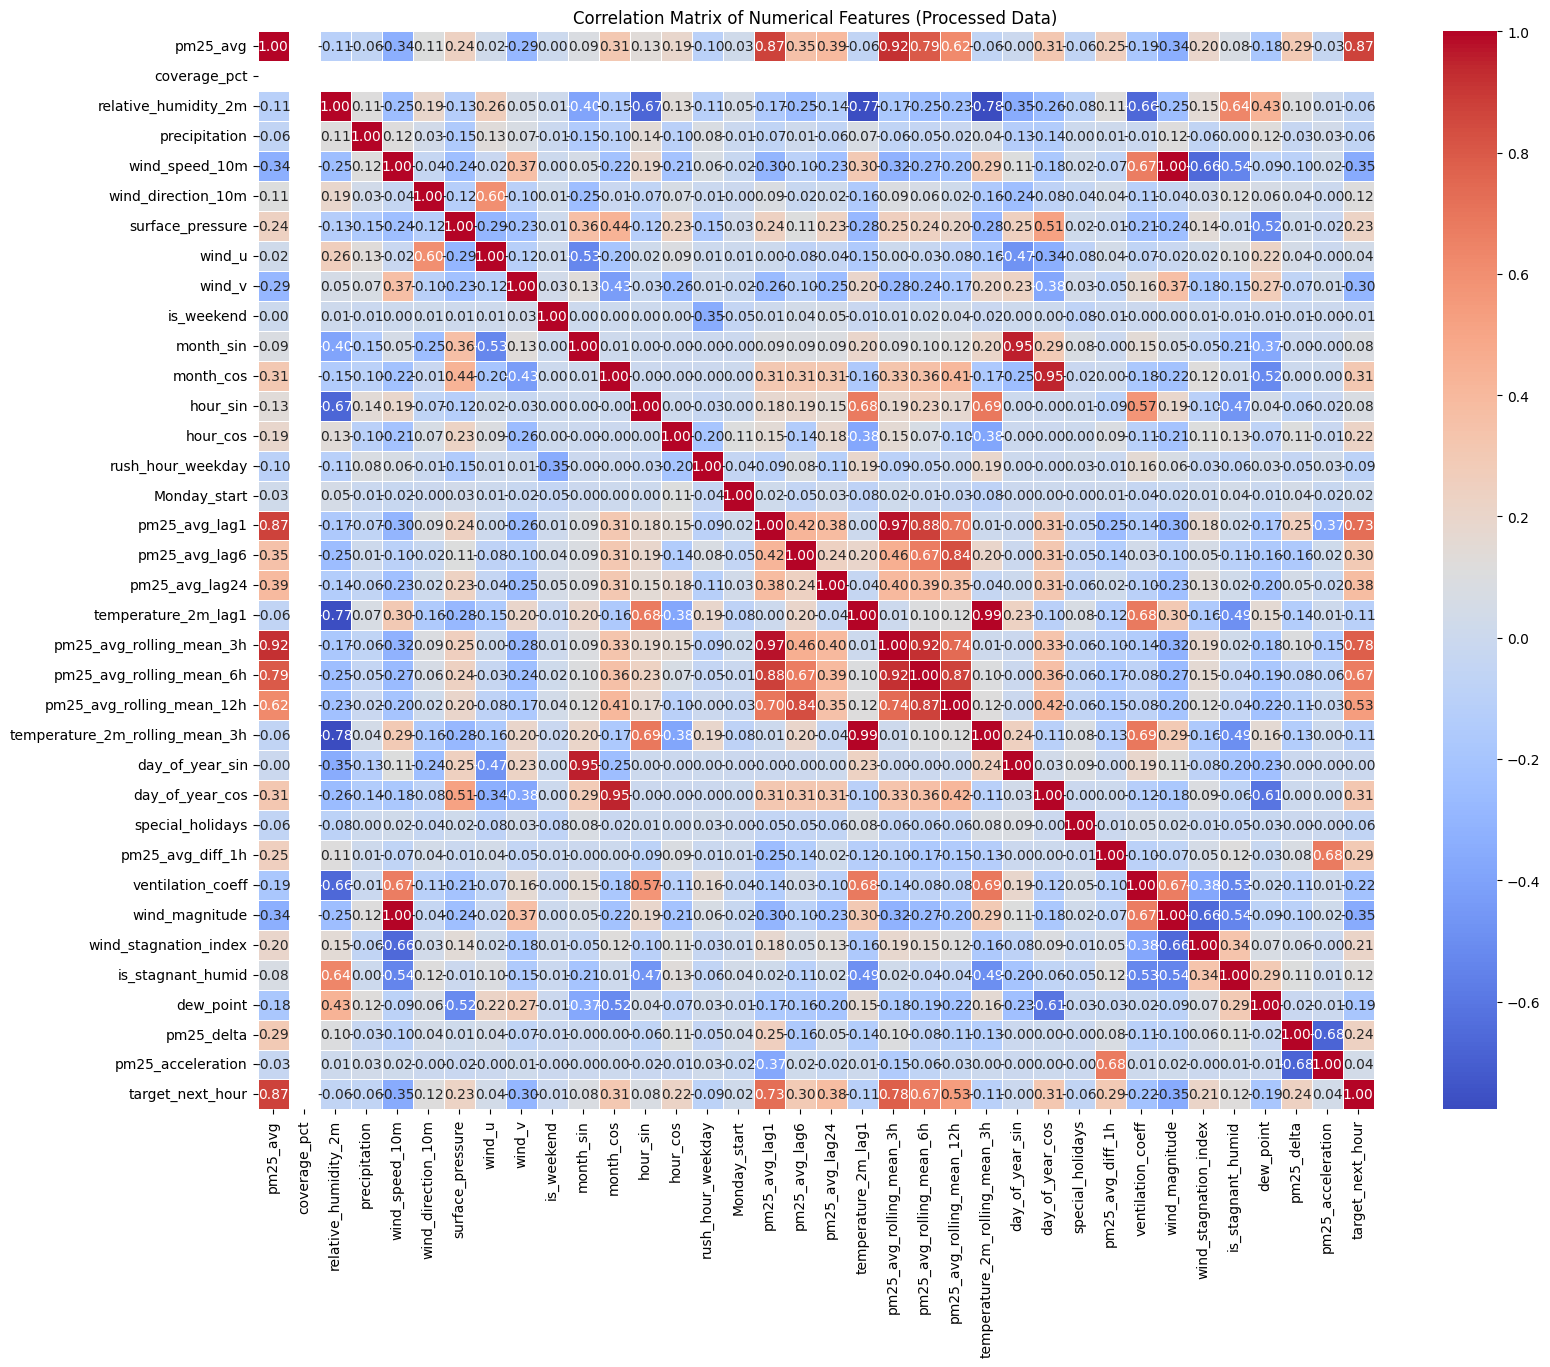

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation matrix for numerical features
# Ensure to re-select numeric types after one-hot encoding if any new numeric columns were created.
correlation_matrix = pm25_df_processed.select_dtypes(include=np.number).corr()

# Display correlation with pm25_avg
print("Correlation with pm25_avg:")
display(correlation_matrix['pm25_avg'].sort_values(ascending=False))

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features (Processed Data)')
plt.show()

In [ ]:
pm25_df_processed.drop(columns=["Season"], inplace=True)

###4. Model training

In [ ]:
# 1. Create the target variable: Predict the NEXT hour
# We shift the current pm25_avg back by 1 so that at time 't', the target is 't+1'
pm25_df_processed['target_next_hour'] = pm25_df_processed['pm25_avg'].shift(-1)

# Drop the last row because it won't have a 'next hour' value to predict
pm25_df_processed.dropna(inplace=True)

# 2. Define Features (X) and Target (y)
X = pm25_df_processed.drop(columns=['target_next_hour'])
y = pm25_df_processed['target_next_hour']

# 3. Time-Series Train-Test Split
# In forecasting, we cannot use future data to predict the past, so we split by index
train_size = int(len(pm25_df_processed) * 0.8)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f'Training set size: {len(X_train)}')
print(f'Testing set size: {len(X_test)}')
print(f'Training from {X_train.index.min()} to {X_train.index.max()}')
print(f'Testing from {X_test.index.min()} to {X_test.index.max()}')

Training set size: 8306
Testing set size: 2077
Training from 0 to 8305
Testing from 8306 to 10382


###4. Model training

In [ ]:
feature_cols = [
    c for c in pm25_df_processed.columns
    if c not in ["datetime", "target_next_hour"]
]

X = pm25_df_processed[feature_cols].copy()
y = pm25_df_processed["target_next_hour"].copy()

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 2. Chia dữ liệu theo tỷ lệ 70% - 15% - 15%
n = len(X)
train_end = int(n * 0.7)
valid_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]
X_valid = X.iloc[train_end:valid_end]
y_valid = y.iloc[train_end:valid_end]
X_test = X.iloc[valid_end:]
y_test = y.iloc[valid_end:]

# 3. Sử dụng đoạn code của bạn để tiền xử lý
categorical_cols = ['time_of_the_day']
numeric_cols = [col for col in X.columns if col not in categorical_cols]

# Tạo preprocessor: mã hóa chuỗi (OneHot) + chuẩn hóa số (Scaler)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ])

# Biến đổi dữ liệu
X_train_proc = preprocessor.fit_transform(X_train)
X_valid_proc = preprocessor.transform(X_valid)
X_test_proc  = preprocessor.transform(X_test)

print(f"Số lượng đặc trưng sau khi xử lý: {X_train_proc.shape[1]}")

Số lượng đặc trưng sau khi xử lý: 38


In [ ]:
# n = len(pm25_df_processed)

# train_end = int(n * 0.7)
# valid_end = int(n * 0.85)

# X_train = X.iloc[:train_end]
# y_train = y.iloc[:train_end]

# X_valid = X.iloc[train_end:valid_end]
# y_valid = y.iloc[train_end:valid_end]

# X_test = X.iloc[valid_end:]
# y_test = y.iloc[valid_end:]

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# 1. Định nghĩa các mô hình
models = {
    "Linear Regression": LinearRegression(),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "CatBoost": CatBoostRegressor(
        loss_function="RMSE",
        eval_metric="RMSE",
        iterations=2000,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=5,
        random_strength=1,
        subsample=0.8,
        bootstrap_type="Bernoulli",
        od_type="Iter",
        od_wait=100,
        verbose=100
    )
}

fe_results = []

# 2. Vòng lặp huấn luyện và đánh giá
for name, model in models.items():
    print(f" đang huấn luyện mô hình: {name}...")

    if name == "CatBoost":
        # CatBoost dùng dữ liệu gốc để xử lý cat_features và dùng eval_set để chống overfitting
        model.fit(
            X_train, y_train,
            cat_features=["time_of_the_day"],
            eval_set=(X_valid, y_valid),
            use_best_model=True
        )
        y_pred = model.predict(X_test)
    else:
        # Các mô hình còn lại dùng dữ liệu đã qua Preprocessor (One-Hot + Scaler)
        model.fit(X_train_proc, y_train)
        y_pred = model.predict(X_test_proc)

    # 3. Tính toán đầy đủ 4 chỉ số
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # 4. Lưu vào danh sách kết quả (đúng 5 cột bạn yêu cầu)
    fe_results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })

# 4. Hiển thị kết quả so sánh
df_fe_res = pd.DataFrame(fe_results)
print("\n--- KẾT QUẢ CÁC MÔ HÌNH SAU FEATURE ENGINEERING ---")
display(df_fe_res.sort_values(by="R2 Score", ascending=False))

 đang huấn luyện mô hình: Linear Regression...
 đang huấn luyện mô hình: K-Nearest Neighbors...
 đang huấn luyện mô hình: Random Forest...
 đang huấn luyện mô hình: XGBoost...
 đang huấn luyện mô hình: CatBoost...
0:	learn: 15.9258823	test: 22.5755581	best: 22.5755581 (0)	total: 8.47ms	remaining: 16.9s
100:	learn: 7.5356382	test: 10.8468768	best: 10.8468768 (100)	total: 727ms	remaining: 13.7s
200:	learn: 7.0473291	test: 10.3704832	best: 10.3704832 (200)	total: 1.42s	remaining: 12.7s
300:	learn: 6.7961723	test: 10.2914451	best: 10.2914451 (300)	total: 2.11s	remaining: 11.9s
400:	learn: 6.5782568	test: 10.2864678	best: 10.2785125 (358)	total: 2.81s	remaining: 11.2s
500:	learn: 6.3871352	test: 10.2720675	best: 10.2665504 (480)	total: 3.52s	remaining: 10.5s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 10.26655042
bestIteration = 480

Shrink model to first 481 iterations.

--- KẾT QUẢ CÁC MÔ HÌNH SAU FEATURE ENGINEERING ---


,Model,MAE,MSE,RMSE,R2 Score
4,CatBoost,4.636855,63.478267,7.967325,0.761472
3,XGBoost,4.767895,67.428458,8.211483,0.746628
2,Random Forest,4.760368,67.602780,8.222091,0.745973
0,Linear Regression,4.988141,72.188782,8.496398,0.728741
1,K-Nearest Neighbors,6.815163,104.532691,10.224123,0.607204


In [ ]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# cat_features = ["Season", "time_of_the_day"]
cat_features = ["time_of_the_day"]
cat_model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=5,
    random_strength=1,
    subsample=0.8,
    bootstrap_type="Bernoulli",
    od_type="Iter",
    od_wait=100,
    verbose=100
)

cat_model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

cat_pred = cat_model.predict(X_test)

cat_mse = mean_squared_error(y_test, cat_pred)
cat_rmse = np.sqrt(cat_mse)
cat_mae = mean_absolute_error(y_test, cat_pred)
cat_r2 = r2_score(y_test, cat_pred)

print("MAE: ", cat_mae)
print("MSE: ", cat_mse)
print("RMSE: ", cat_rmse)
print("R² Score: ", cat_r2)

0:	learn: 15.9258823	test: 22.5755581	best: 22.5755581 (0)	total: 6.56ms	remaining: 13.1s
100:	learn: 7.5356382	test: 10.8468768	best: 10.8468768 (100)	total: 1.14s	remaining: 21.4s
200:	learn: 7.0473291	test: 10.3704832	best: 10.3704832 (200)	total: 2.4s	remaining: 21.5s
300:	learn: 6.7961723	test: 10.2914451	best: 10.2914451 (300)	total: 3.07s	remaining: 17.3s
400:	learn: 6.5782568	test: 10.2864678	best: 10.2785125 (358)	total: 3.78s	remaining: 15.1s
500:	learn: 6.3871352	test: 10.2720675	best: 10.2665504 (480)	total: 4.49s	remaining: 13.4s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 10.26655042
bestIteration = 480

Shrink model to first 481 iterations.
MAE:  4.636854731921366
MSE:  63.47826737035889
RMSE:  7.9673249820977485
R² Score:  0.7614717179306838


In [ ]:
cat_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": cat_model.get_feature_importance()
}).sort_values("importance", ascending=False)

print(cat_importance.head(20))

                           feature  importance
0                         pm25_avg   69.051640
28                pm25_avg_diff_1h    6.642261
21        pm25_avg_rolling_mean_3h    2.609838
17                   pm25_avg_lag1    1.318541
14                 time_of_the_day    1.317788
13                        hour_cos    1.253933
34                      pm25_delta    1.083749
29               ventilation_coeff    1.075001
35               pm25_acceleration    1.039042
24  temperature_2m_rolling_mean_3h    0.888940
18                   pm25_avg_lag6    0.884156
12                        hour_sin    0.853742
20             temperature_2m_lag1    0.843228
33                       dew_point    0.836915
25                 day_of_year_sin    0.803676
4                   wind_speed_10m    0.773194
26                 day_of_year_cos    0.740348
23       pm25_avg_rolling_mean_12h    0.731407
19                  pm25_avg_lag24    0.708134
2             relative_humidity_2m    0.677819


Next-hour PM2.5 is driven much more by immediate autoregressive memory and short-term physical conditions than by coarse contextual or weather-only signals.

# Analys

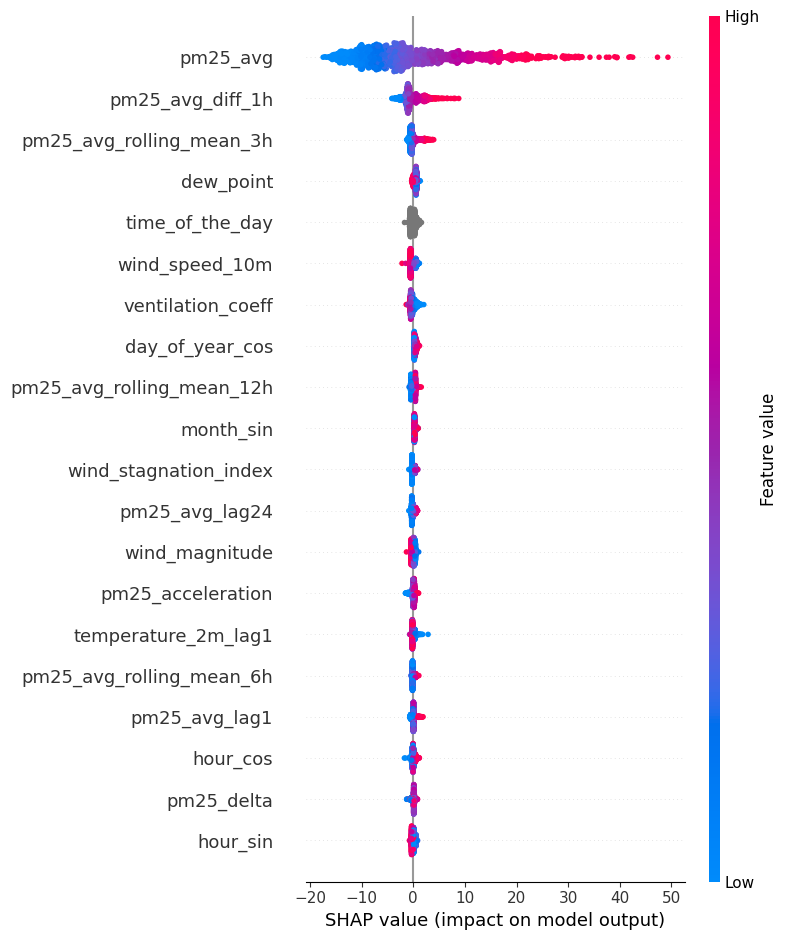

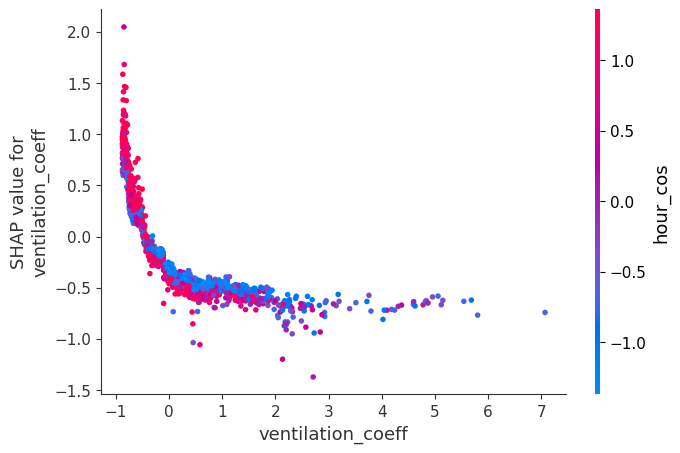

In [ ]:
import shap

# 1. Khởi tạo đối tượng giải thích (Explainer)
# Lưu ý: CatBoost hỗ trợ SHAP trực tiếp rất nhanh
explainer = shap.TreeExplainer(cat_model) # cat_model là mô hình CatBoost đã huấn luyện
shap_values = explainer.shap_values(X_test)

# 2. Vẽ Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="dot")

# 3. Vẽ biểu đồ sự phụ thuộc cho biến FE quan trọng (ví dụ: ventilation_coeff)
if 'ventilation_coeff' in X_test.columns:
    shap.dependence_plot('ventilation_coeff', shap_values, X_test)